# Ejemplo guía — Fase 1 (EDA) — Detección de Drift
## Caso: >[REDACTADO]<

Este notebook es un ejemplo guía de cómo abordar
la **Fase 1 (EDA)** del **Practico Final**
con foco en lo que específicamente en *"análisis univariado/multivariado,
detección de fuga de datos potencial"*, y en sentar las bases para justificar más
adelante el por qué el monitoreo de drift importa en el caso elegido.

Es una plantilla de cómo razonar y estructurar la Fase 1, con un dataset que **no está en la lista de casos ya usados en el curso** es sobre los viajes de taxi de Nueva York, con un evento real y documentado (el shock del COVID-19).

## Contexto del caso de negocio

Una plataforma de taxis en Nueva York quiere estimar, **al momento en que un pasajero
solicita un viaje**, cuánto va a durar y/o cuánto va a costar (para informar un tiempo
estimado y una tarifa aproximada antes de empezar el viaje). Entrena un modelo con
datos históricos de viajes.

**¿Por qué el drift es relevante acá?** El enunciado del práctico menciona
explícitamente los *"shocks externos"* como una causa de drift. No hay un caso más
claro de shock externo documentado públicamente que el arranque de la pandemia de
COVID-19 en Nueva York en marzo de 2020: cuarentena total, calles vacías, un cambio
radical y repentino en cuántos viajes se piden, qué tan largos son, a qué hora del día
y cómo se pagan. **Un modelo entrenado con datos de enero de 2020 se enfrentaría, un
mes y medio después, a un mundo completamente distinto.**

Vamos a comparar:
- **Referencia:** enero 2020 (mes normal, pre-pandemia)
- **Producción simulada (pero con datos 100% reales):** marzo 2020 (inicio del shock),
  abril 2020 (cuarentena total, el peor momento) y julio 2020 (reapertura parcial)

## 0. Setup

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
print("Corriendo en Colab:", IN_COLAB)

Corriendo en Colab: True


In [2]:
%%capture
!pip install -q "pandas>=2.0" "pyarrow>=14" "numpy>=1.26" matplotlib seaborn requests

In [3]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = pathlib.Path("data_taxi")
DATA_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 40_000  # por período -- suficiente para EDA, liviano para Colab

## Fase 1 — EDA (RAA2)

### 1.1 Descarga de datos

Los datos de TLC se publican en Parquet, un mes por archivo, en una URL pública
estable (sin autenticación). Bajamos 4 meses: uno de referencia y tres de
"producción" con drift creciente por el COVID.

In [4]:
BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"
PERIODS = {
    "2020-01": "referencia (pre-COVID)",
    "2020-03": "inicio del shock",
    "2020-04": "cuarentena total",
    "2020-07": "reapertura parcial",
}

COLUMNS = [
    "VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag",
    "PULocationID", "DOLocationID", "payment_type", "fare_amount", "extra",
    "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
    "total_amount", "congestion_surcharge",
]  # se excluye 'airport_fee': en 2020 esa columna no existía todavía / viene 100% nula

for period in PERIODS:
    path = DATA_DIR / f"yellow_tripdata_{period}.parquet"
    if path.exists():
        continue
    url = f"{BASE_URL}/yellow_tripdata_{period}.parquet"
    print(f"Descargando {url} ...")
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    path.write_bytes(r.content)

zones_path = DATA_DIR / "taxi_zone_lookup.csv"
if not zones_path.exists():
    zones_path.write_bytes(requests.get(f"{BASE_URL.rsplit('/', 1)[0]}/misc/taxi_zone_lookup.csv").content)
zones = pd.read_csv(zones_path)
print("Listo. Archivos en", DATA_DIR.resolve())

Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-01.parquet ...
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-03.parquet ...
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-04.parquet ...
Descargando https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2020-07.parquet ...
Listo. Archivos en /content/data_taxi


In [5]:
import pyarrow.parquet as pq

# El conteo TOTAL de viajes por mes se puede leer del metadata del parquet sin
# cargar el archivo completo a memoria -- y ya de entrada cuenta la historia:
volumen_total = {}
for period, label in PERIODS.items():
    path = DATA_DIR / f"yellow_tripdata_{period}.parquet"
    n = pq.ParquetFile(path).metadata.num_rows
    volumen_total[period] = n
    print(f"{period} ({label}): {n:,} viajes")

volumen_df = pd.Series(volumen_total, name="n_viajes").to_frame()
volumen_df["variacion_vs_enero"] = (volumen_df["n_viajes"] / volumen_df.loc["2020-01", "n_viajes"] - 1)
volumen_df

2020-01 (referencia (pre-COVID)): 6,405,008 viajes
2020-03 (inicio del shock): 3,007,687 viajes
2020-04 (cuarentena total): 238,073 viajes
2020-07 (reapertura parcial): 800,412 viajes


,n_viajes,variacion_vs_enero
2020-01,6405008,0.000000
2020-03,3007687,-0.530416
2020-04,238073,-0.962830
2020-07,800412,-0.875033


**Primer hallazgo, y ni siquiera abrimos los datos todavía:** el volumen de viajes cae
más del 96% entre enero y abril de 2020. Esto ya es evidencia de drift al nivel más
básico posible (el volumen de la población que llega al modelo) antes de mirar una
sola distribución de features. Vale la pena mostrar esto primero en cualquier EDA
orientado a drift: **¿cuánta "señal" está llegando, y cambió el volumen?**

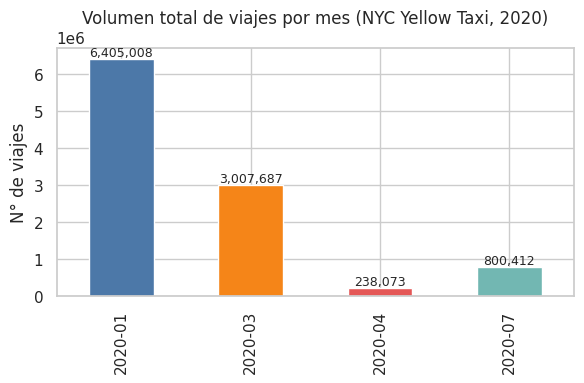

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
volumen_df["n_viajes"].plot(kind="bar", ax=ax, color=["#4C78A8", "#F58518", "#E45756", "#72B7B2"])
ax.set_title("Volumen total de viajes por mes (NYC Yellow Taxi, 2020)")
ax.set_ylabel("N° de viajes")
for i, v in enumerate(volumen_df["n_viajes"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
def cargar_muestra(period: str, n=SAMPLE_SIZE) -> pd.DataFrame:
    path = DATA_DIR / f"yellow_tripdata_{period}.parquet"
    df = pd.read_parquet(path, columns=COLUMNS)
    # Filtro mínimo de fecha: algunos archivos de TLC traen registros mal cargados
    # con fecha fuera del mes correspondiente (ver limpieza de anomalías más abajo).
    y, m = int(period[:4]), int(period[5:7])
    df = df[(df["tpep_pickup_datetime"].dt.year == y) & (df["tpep_pickup_datetime"].dt.month == m)]
    if len(df) > n:
        df = df.sample(n=n, random_state=RANDOM_STATE)
    return df.reset_index(drop=True)


ref = cargar_muestra("2020-01")
print("Muestra de referencia (enero 2020):", ref.shape)
ref.head()

Muestra de referencia (enero 2020): (40000, 18)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2,2020-01-01 10:07:43,2020-01-01 10:18:57,1.0,3.69,1.0,N,237,79,1,12.5,0.0,0.5,3.95,0.0,0.3,19.75,2.5
1,2,2020-01-27 08:05:38,2020-01-27 08:08:11,2.0,1.33,1.0,N,50,246,1,5.5,0.0,0.5,1.00,0.0,0.3,9.80,2.5
2,2,2020-01-24 10:10:24,2020-01-24 10:20:24,1.0,1.09,1.0,N,229,141,1,7.5,0.0,0.5,2.16,0.0,0.3,12.96,2.5
3,2,2020-01-31 20:53:53,2020-01-31 21:00:43,1.0,1.29,1.0,N,239,237,1,6.5,0.5,0.5,1.50,0.0,0.3,11.80,2.5
4,2,2020-01-21 11:37:59,2020-01-21 11:48:44,3.0,1.46,1.0,N,237,263,1,9.0,0.0,0.5,1.23,0.0,0.3,13.53,2.5


### 1.2 Estructura general y calidad de datos

Antes de analizar distribuciones, miramos qué tan "sucios" están los datos.

In [8]:
ref.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               40000 non-null  int64         
 1   tpep_pickup_datetime   40000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  40000 non-null  datetime64[us]
 3   passenger_count        39616 non-null  float64       
 4   trip_distance          40000 non-null  float64       
 5   RatecodeID             39616 non-null  float64       
 6   store_and_fwd_flag     39616 non-null  object        
 7   PULocationID           40000 non-null  int64         
 8   DOLocationID           40000 non-null  int64         
 9   payment_type           40000 non-null  int64         
 10  fare_amount            40000 non-null  float64       
 11  extra                  40000 non-null  float64       
 12  mta_tax                40000 non-null  float64       
 13  t

In [9]:
print("Nulos por columna:")
print(ref.isna().sum()[ref.isna().sum() > 0])
print()

n = len(ref)
anomalias = {
    "fare_amount o total_amount negativos": ((ref["fare_amount"] < 0) | (ref["total_amount"] < 0)).sum(),
    "trip_distance == 0": (ref["trip_distance"] == 0).sum(),
    "passenger_count == 0": (ref["passenger_count"] == 0).sum(),
    "dropoff <= pickup (duración <= 0)": (ref["tpep_dropoff_datetime"] <= ref["tpep_pickup_datetime"]).sum(),
    "duración > 3 horas": (((ref["tpep_dropoff_datetime"] - ref["tpep_pickup_datetime"]).dt.total_seconds() / 60) > 180).sum(),
    "trip_distance > 100 millas": (ref["trip_distance"] > 100).sum(),
}
for k, v in anomalias.items():
    print(f"{k}: {v} ({v/n:.2%})")

Nulos por columna:
passenger_count         384
RatecodeID              384
store_and_fwd_flag      384
congestion_surcharge    384
dtype: int64

fare_amount o total_amount negativos: 122 (0.30%)
trip_distance == 0: 413 (1.03%)
passenger_count == 0: 702 (1.75%)
dropoff <= pickup (duración <= 0): 24 (0.06%)
duración > 3 horas: 72 (0.18%)
trip_distance > 100 millas: 0 (0.00%)


In [10]:
# ¿Los timestamps corruptos son casos aislados o un patrón? Vale la pena mirarlos.
fuera_de_rango = ref[(ref["tpep_pickup_datetime"].dt.year != 2020) | (ref["tpep_pickup_datetime"].dt.month != 1)]
print("Pickups fuera de enero-2020 en la muestra:", len(fuera_de_rango))

ejemplos_raros = ref[(ref["trip_distance"] == 0) & (ref["fare_amount"] > 20)]
print("\nViajes con distancia 0 pero tarifa alta (posible error de sensor/GPS, no necesariamente fraude):")
ejemplos_raros[["trip_distance", "fare_amount", "payment_type", "RatecodeID"]].head()

Pickups fuera de enero-2020 en la muestra: 0

Viajes con distancia 0 pero tarifa alta (posible error de sensor/GPS, no necesariamente fraude):


,trip_distance,fare_amount,payment_type,RatecodeID
272,0.0,61.42,1,5.0
837,0.0,52.00,1,2.0
1015,0.0,65.00,1,5.0
1525,0.0,30.20,1,1.0
1618,0.0,117.00,1,5.0


**Decisión de limpieza (documentada, no solo `.dropna()`):**
- `passenger_count` y `RatecodeID` nulos (mismo pequeño lote de filas, probablemente
  un problema puntual de un proveedor/VendorID).
  Se documentan y se excluyen del
  análisis univariado de esas columnas, sin descartar la fila entera de otras
  columnas que sí están completas.
- Duraciones ≤ 0 o > 3 horas, distancias 0 con tarifa alta, y tarifas negativas: se
  excluyen del análisis de distribuciones (para no distorsionar histogramas/medias)
  pero **no se botan silenciosamente**. Son candidatas a reglas de negocio
  (reembolsos, viajes cancelados, errores de GPS) que ameritarían una conversación con
  el equipo de datos en un caso real, no una decisión unilateral de EDA.

In [11]:
def limpiar(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dur_min = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
    mask = (
        (df["fare_amount"] >= 0)
        & (df["total_amount"] >= 0)
        & (df["trip_distance"] > 0)
        & (df["trip_distance"] <= 100)
        & (dur_min > 0)
        & (dur_min <= 180)
    )
    df = df[mask].copy()
    df["trip_duration_min"] = dur_min[mask]
    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour
    df["pickup_dow"] = df["tpep_pickup_datetime"].dt.day_name()
    return df.reset_index(drop=True)


ref_clean = limpiar(ref)
print(f"Filas antes de limpiar: {len(ref)}  ->  después: {len(ref_clean)}  ({len(ref_clean)/len(ref):.1%} retenido)")

Filas antes de limpiar: 40000  ->  después: 39396  (98.5% retenido)


### 1.3 Análisis univariado

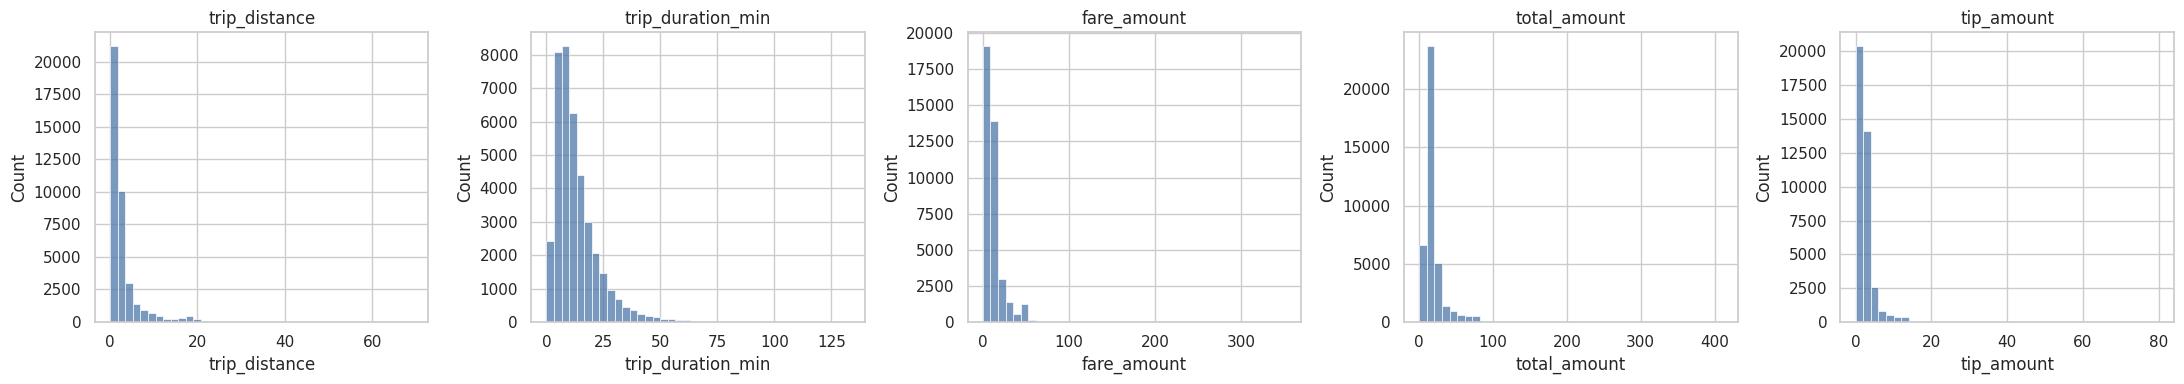

,trip_distance,trip_duration_min,fare_amount,total_amount,tip_amount
count,39396.000000,39396.000000,39396.000000,39396.000000,39396.000000
mean,2.925882,13.127970,12.563548,18.556451,2.181426
std,3.827821,9.980786,11.380138,14.043103,2.592998
min,0.010000,0.016667,0.000000,0.000000,0.000000
25%,0.980000,6.416667,6.500000,11.160000,0.000000
50%,1.600000,10.433333,9.000000,14.160000,1.950000
75%,2.950000,16.737500,13.500000,19.750000,2.860000
max,69.400000,133.016667,352.500000,410.670000,80.000000


In [12]:
num_cols = ["trip_distance", "trip_duration_min", "fare_amount", "total_amount", "tip_amount"]
fig, axes = plt.subplots(1, len(num_cols), figsize=(22, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(ref_clean[col], bins=40, ax=ax, color="#4C78A8")
    ax.set_title(col)
plt.tight_layout()
plt.show()

ref_clean[num_cols].describe()

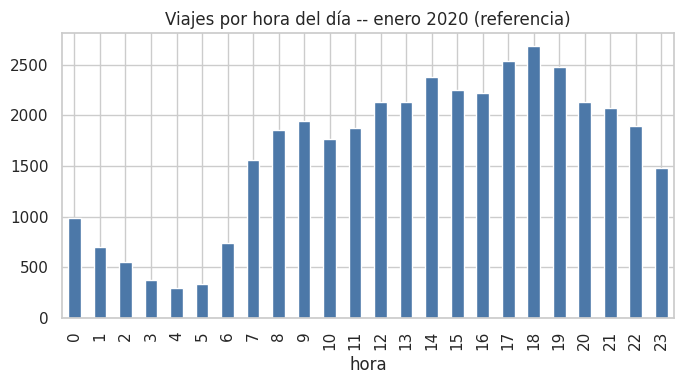

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ref_clean["pickup_hour"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Viajes por hora del día -- enero 2020 (referencia)")
ax.set_xlabel("hora")
plt.tight_layout()
plt.show()

Se ven las dos horas pico típicas de una ciudad que va a trabajar (mañana y tarde).
Más abajo comparamos este patrón contra abril 2020, vale la pena anticipar una
hipótesis antes de mirar el resultado (¿desaparece la hora punta?, ¿se aplana?) y
después contrastarla con el dato real, en vez de asumir cuál "debería" ser el efecto.

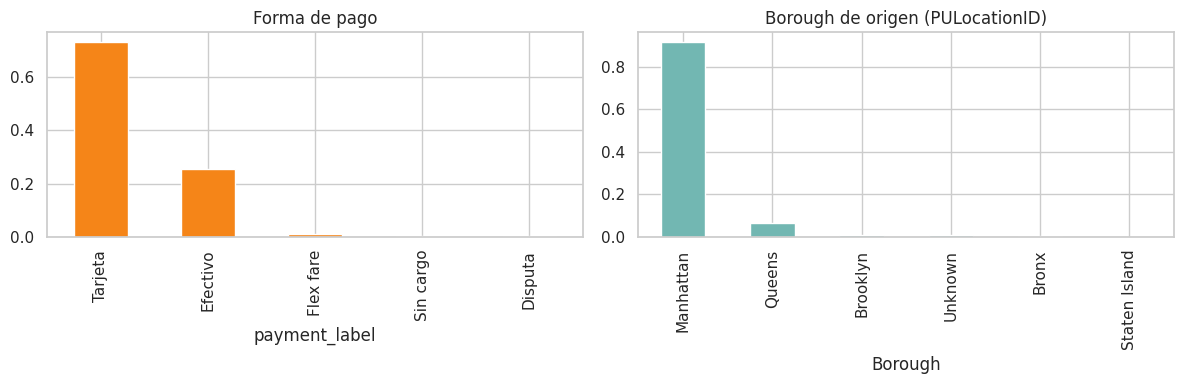

In [14]:
cat_cols_info = []
payment_labels = {1: "Tarjeta", 2: "Efectivo", 3: "Sin cargo", 4: "Disputa", 0: "Flex fare", 5: "Desconocido"}
ref_clean["payment_label"] = ref_clean["payment_type"].map(payment_labels).fillna("Otro")

ref_zoned = ref_clean.merge(zones[["LocationID", "Borough"]], left_on="PULocationID", right_on="LocationID", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ref_clean["payment_label"].value_counts(normalize=True).plot(kind="bar", ax=axes[0], color="#F58518")
axes[0].set_title("Forma de pago")
ref_zoned["Borough"].value_counts(normalize=True).plot(kind="bar", ax=axes[1], color="#72B7B2")
axes[1].set_title("Borough de origen (PULocationID)")
plt.tight_layout()
plt.show()

Casi todos los viajes de la muestra salen de Manhattan, razonable para taxis amarillos (a diferencia de las apps tipo Uber/Lyft, que cubren más los otros boroughs).

### 1.4 Análisis multivariado

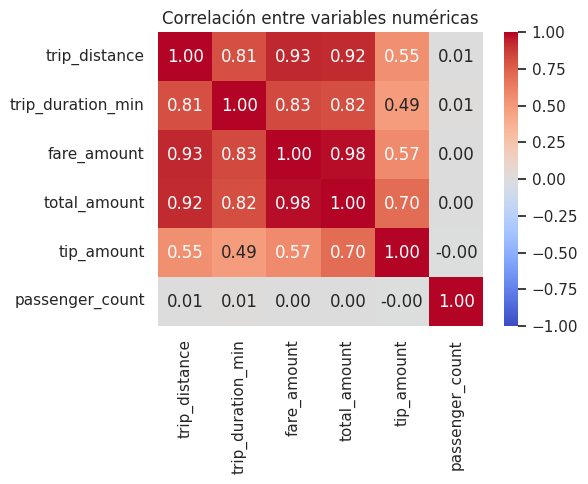

In [15]:
corr = ref_clean[["trip_distance", "trip_duration_min", "fare_amount", "total_amount", "tip_amount", "passenger_count"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

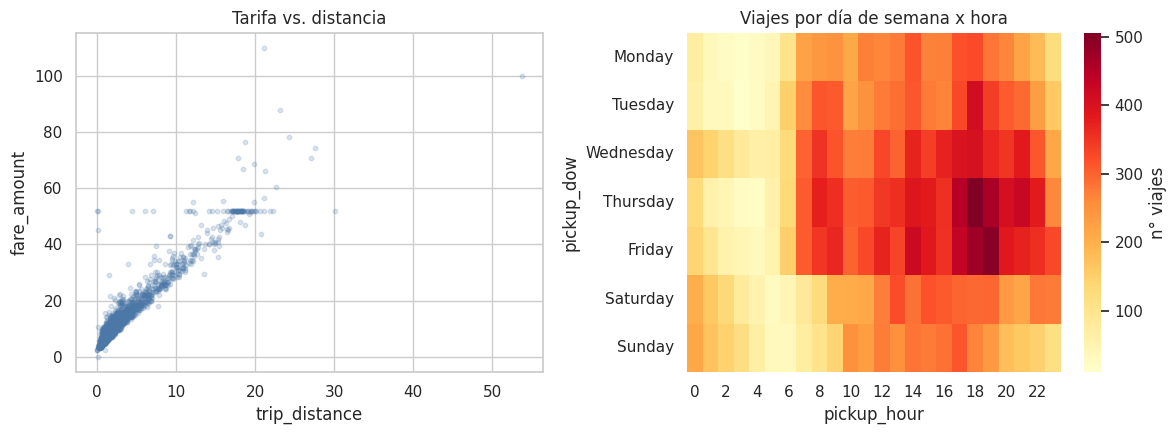

In [16]:
sample_plot = ref_clean.sample(n=3000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(sample_plot["trip_distance"], sample_plot["fare_amount"], alpha=0.2, s=10, color="#4C78A8")
axes[0].set_xlabel("trip_distance"); axes[0].set_ylabel("fare_amount")
axes[0].set_title("Tarifa vs. distancia")

pivot = ref_clean.pivot_table(index="pickup_dow", columns="pickup_hour", values="fare_amount", aggfunc="count")
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = pivot.reindex(dow_order)
sns.heatmap(pivot, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "n° viajes"})
axes[1].set_title("Viajes por día de semana x hora")
plt.tight_layout()
plt.show()

**Lectura:** `fare_amount` y `trip_distance` están fuertemente correlacionados (era
esperable, la tarifa se calcula en gran parte por distancia/tiempo), son casi
redundantes como features, algo a tener en cuenta si más adelante se interpreta
importancia de variables. El heatmap día×hora muestra el patrón clásico de una ciudad
laboral: picos en horario punta de lunes a viernes, más parejo el fin de semana.

### 1.5 Detección de fuga de datos potencial

El objetivo de negocio es estimar duración/tarifa **al momento en que el pasajero pide
el viaje** (antes de subirse). Eso obliga a preguntarse, columna por columna: **¿esta
variable se conoce en ese momento, o solo se conoce después/al final del viaje?**

In [17]:
componentes = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge", "congestion_surcharge"]
suma_componentes = ref_clean[componentes].sum(axis=1)
diferencia = ref_clean["total_amount"] - suma_componentes

print("Correlación total_amount vs. suma de sus componentes:", np.corrcoef(ref_clean["total_amount"], suma_componentes)[0, 1].round(4))
print("\nDiferencias más comunes (redondeadas):")
print(diferencia.round(2).value_counts().head(5))

Correlación total_amount vs. suma de sus componentes: 0.9966

Diferencias más comunes (redondeadas):
 0.00    27227
-2.50    12068
 1.95       97
 4.95        3
 2.50        1
Name: count, dtype: int64


`total_amount` correlaciona ~0.997 con la suma de sus propios componentes (`fare_amount + extra + mta_tax + tip_amount + tolls_amount + improvement_surcharge +
congestion_surcharge`), es, casi por definición, la **suma post-viaje** de cargos
que en su mayoría no existen todavía cuando el pasajero pide el auto. La diferencia
más común no es cero sino exactamente **-2.50**, el valor del `congestion_surcharge`:
una inconsistencia real y documentada de esta fuente de datos (una porción de los
registros no incluye ese cargo en el total). Vale la pena mostrar este tipo de
"investigación de un número raro" en el informe, es mejor EDA que asumir sin
verificar.

**Conclusión de fuga de datos para este caso:** si el objetivo es predecir "al pedir
el viaje", las siguientes columnas **no pueden usarse como features** porque no
existen todavía en ese momento (se conocen recién al terminar el viaje, o después):
`tpep_dropoff_datetime`, `total_amount`, `tip_amount`, `tolls_amount`,
`trip_distance` real (solo se conoce una estimación, no el valor exacto que terminó
teniendo el viaje) y, dependiendo del modelo de negocio, `DOLocationID` (¿el pasajero
declara el destino al pedir el auto, o el taxi lo recoge en la calle sin saber a dónde
va?, la respuesta cambia qué es fuga y qué no, y **depende del caso de uso
concreto**, no es una regla universal).

## 1.6 Primera mirada al drift (referencia vs. producción)

Esto **no reemplaza** la evaluación del drift posterior (ahí se calculan PSI/KS/Chi² de forma
formal, con umbrales justificados), es la evidencia descriptiva que, en la EDA,
justifica por qué vale la pena seguir invirtiendo en construir un sistema de
monitoreo para este caso.

In [18]:
periodos_prod = ["2020-01", "2020-03", "2020-04", "2020-07"]
muestras = {p: limpiar(cargar_muestra(p)) for p in periodos_prod}

resumen = pd.DataFrame({
    p: {
        "n_viajes_totales_mes": volumen_total[p],
        "trip_distance_media": muestras[p]["trip_distance"].mean(),
        "fare_amount_media": muestras[p]["fare_amount"].mean(),
        "trip_duration_min_media": muestras[p]["trip_duration_min"].mean(),
        "%_pago_efectivo": (muestras[p]["payment_type"] == 2).mean(),
    }
    for p in periodos_prod
}).T
resumen

,n_viajes_totales_mes,trip_distance_media,fare_amount_media,trip_duration_min_media,%_pago_efectivo
2020-01,6405008.0,2.925882,12.563548,13.127970,0.252868
2020-03,3007687.0,2.917200,12.398597,13.096623,0.244662
2020-04,238073.0,3.081018,11.515359,9.820042,0.354983
2020-07,800412.0,3.194412,13.111958,12.132566,0.302972


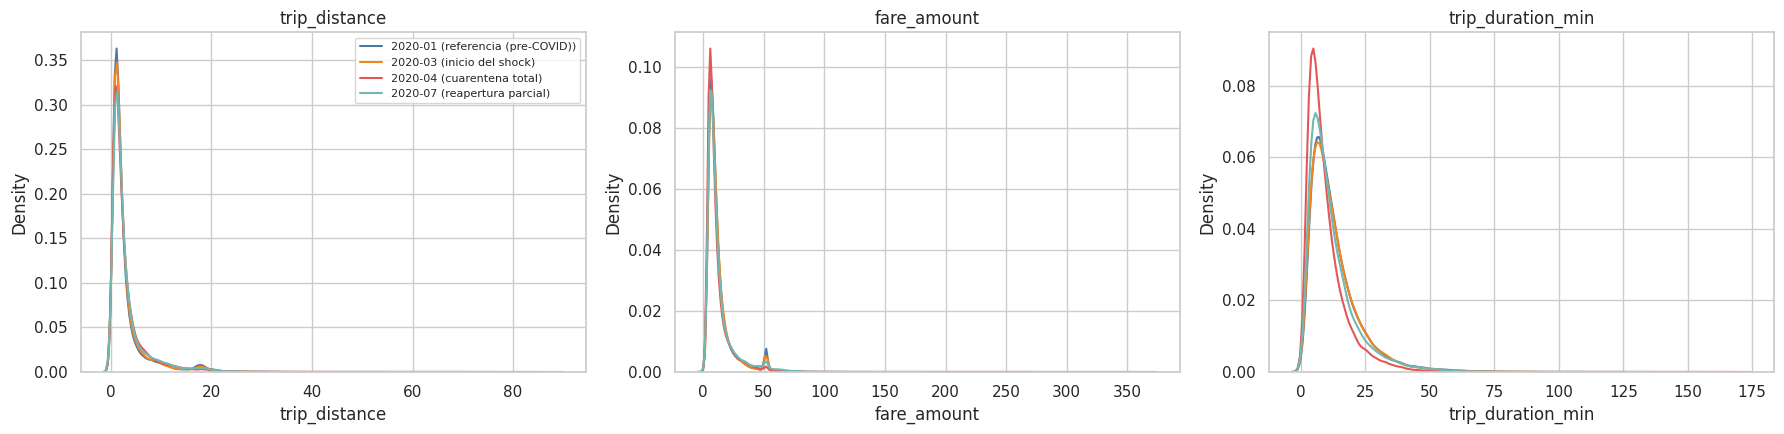

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, col in zip(axes, ["trip_distance", "fare_amount", "trip_duration_min"]):
    for p, color in zip(periodos_prod, ["#4C78A8", "#F58518", "#E45756", "#72B7B2"]):
        sns.kdeplot(muestras[p][col], ax=ax, label=f"{p} ({PERIODS[p]})", color=color)
    ax.set_title(col)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

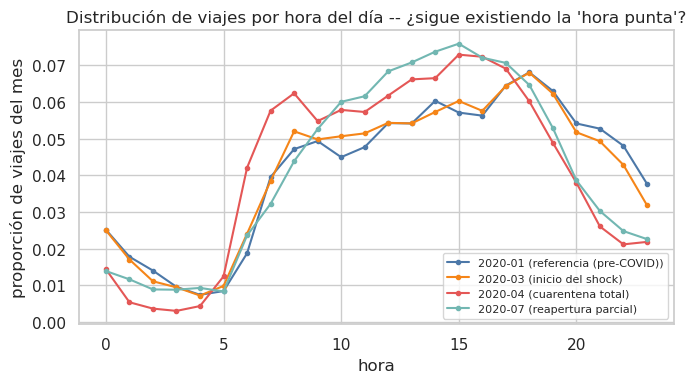

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for p, color in zip(periodos_prod, ["#4C78A8", "#F58518", "#E45756", "#72B7B2"]):
    muestras[p]["pickup_hour"].value_counts(normalize=True).sort_index().plot(ax=ax, label=f"{p} ({PERIODS[p]})", color=color, marker="o", markersize=3)
ax.set_title("Distribución de viajes por hora del día -- ¿sigue existiendo la 'hora punta'?")
ax.set_xlabel("hora"); ax.set_ylabel("proporción de viajes del mes")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Lectura de negocio (lo que iría en un informe ejecutivo), basada en los números de
la tabla y los gráficos de arriba, no en supuestos:** en abril de 2020 no solo caen
los viajes un 96%, los que quedan son distintos. La duración promedio baja de 13.1 a
9.8 minutos (calles vacías, se viaja más rápido a la misma distancia). La franja de
madrugada (0-4am, tráfico típico de vida nocturna) cae de ~7% a ~3% de los viajes del
mes, proporcionalmente el segmento más golpeado. Y, contra lo que uno esperaría
("menos efectivo por contagio"), **el pago en efectivo sube** de 25% a 35%: la
explicación más plausible no es que la gente prefiera pagar distinto, sino que
**cambió quién sigue viajando**, el commuter de oficina que paga con tarjeta
corporativa prácticamente desaparece, y una porción mayor de los viajes restantes son
de trabajadores esenciales, con otro patrón de pago. Para julio varias métricas
recuperan terreno pero sin volver a los niveles de enero, consistente con una
reapertura parcial.

Este último punto es una buena lección de EDA: la primera hipótesis intuitiva
("higiene → menos efectivo") era razonable, pero **el dato la contradice**, y la
explicación correcta requiere pensar en composición de la población, no solo en el
promedio. Es exactamente el tipo de matiz que un sistema de monitoreo de drift no explica solo, detecta que la distribución de `payment_type` cambió, pero el
**por qué** sigue siendo trabajo humano de interpretación.

## Conclusiones del EDA

**Lo que este EDA ya deja listo para las fases siguientes:**
- Un criterio de limpieza documentado (Fase 2 lo puede reutilizar tal cual).
- Una lista clara de qué columnas NO deben usarse como features por fuga de datos, y
  por qué, condicionado explícitamente al momento de la predicción.
- Evidencia de que el drift es real y de que su magnitud es enorme (no un matiz sutil), justifica de sobra invertir en Fase 4.
- Un corte temporal natural (`2020-01` como referencia, meses siguientes como
  "producción") para alimentar la simulación de la Fase 3 sin tener que inventar
  perturbaciones artificiales, a diferencia de datasets sin eje temporal, acá el
  drift ya viene "de fábrica".

### Cómo replicar esto con tu propio dataset

1. Antes de tocar una distribución, mira el **volumen/tamaño de la población en el
   tiempo** (o el equivalente en tu dataset), a veces la señal de drift más obvia es
   la más simple.
2. Cuantifica anomalías de calidad de datos con números, no con una frase genérica
   ("hay outliers"): ¿cuántas filas, qué regla las detecta, qué decidiste hacer y por
   qué.
3. Para cada feature candidata, pregúntate explícitamente: **¿se conoce en el momento
   en que el modelo tendría que predecir, en tu caso de uso real?** Esa pregunta, más
   que cualquier técnica automática, es la que detecta la fuga de datos.
4. Si tu dataset no tiene eje temporal real, esto mismo se puede armar simulando un
   corte con muestreo sesgado o perturbación de variables (ver los ejemplos de
   referencia de la cátedra), la estructura del análisis es la misma.